# Projeto Final Aplicado a Ciência de Dados
## Deteção de Outliers em Contratos Públicos e Previsão do Montante de Adjudição

## Grupo 08
## Membros:
###          - Afonso Alexandre nº 123425;
###          - André  Freitas nº 123409;
###          - Gonçalo Vilhena nº 123384;
###          - Rodolfo Nardy nº 123419

In [3]:
import pandas as pd
import os
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

In [4]:
file_path = "contratos_total.csv"
df = pd.read_csv(file_path, low_memory=False)

In [5]:
cols_datas = [
    'dataPublicacao',
    'dataCelebracaoContrato',
    'dataDecisaoAdjudicacao',
    'dataFechoContrato'
]

df[cols_datas] = df[cols_datas].apply(pd.to_datetime, errors='coerce')

df['anodataPublicacao'] = df['dataPublicacao'].dt.year

contratos_por_ano = df.groupby(df['dataPublicacao'].dt.year).size()

print(contratos_por_ano)

dataPublicacao
2008         1
2009         8
2013         1
2015     88168
2016    110635
2017    127042
2018    121840
2019    144666
2020    164013
2021    192017
2022    186984
2023    193079
2024    224279
2025    254755
2026     35758
dtype: int64


In [6]:
df['anodataCelebracaoContrato'] = df['dataCelebracaoContrato'].dt.year

contratos_por_ano = df.groupby(df['dataCelebracaoContrato'].dt.year).size()

print(contratos_por_ano)

dataCelebracaoContrato
2015.0    107626
2016.0    114893
2017.0    128577
2018.0    127873
2019.0    145470
2020.0    149769
2021.0    177419
2022.0    174064
2023.0    192492
2024.0    225181
2025.0    236168
2026.0     22471
dtype: int64


In [7]:
df['anodataFechoContrato'] = df['dataFechoContrato'].dt.year

contratos_por_ano = df.groupby(df['dataFechoContrato'].dt.year).size()

print(contratos_por_ano)

dataFechoContrato
2000.0        3
2010.0        1
2012.0        1
2013.0        1
2014.0       18
2015.0    30081
2016.0    37190
2017.0    43757
2018.0    45135
2019.0    49878
2020.0    75422
2021.0    70779
2022.0    69747
2023.0    66415
2024.0    59535
2025.0    49828
2026.0     3100
dtype: int64


In [8]:
df[df["anodataFechoContrato"]==2000]

,idcontrato,nAnuncio,TipoAnuncio,idINCM,tipoContrato,idprocedimento,tipoprocedimento,objectoContrato,descContrato,adjudicante,...,CritMateriais,concorrentes,linkPecasProc,Observacoes,ContratEcologico,fundamentAjusteDireto,Ano,anodataPublicacao,anodataCelebracaoContrato,anodataFechoContrato
439639,5649808,NaN,NaN,NaN,Aquisição de serviços,4078485,Ajuste Direto Regime Geral,Processo 19000269 Renovação contrato 69/2017_R...,Processo 19000269 Renovação contrato 69/2017_R...,503135593 - Administração Regional de Saúde do...,...,Não,NaN,NaN,NaN,Não,ausência de recursos próprios,2018,2019,2018.0,2000.0
441480,5649729,NaN,NaN,NaN,Aquisição de serviços,4078454,Ajuste Direto Regime Geral,Processo 19000269-Renovação contrato 68/2017 -...,Processo 19000269 Renovação contrato 68/2017_R...,503135593 - Administração Regional de Saúde do...,...,Não,NaN,NaN,NaN,Não,ausência de recursos próprios,2018,2019,2018.0,2000.0
789451,8366228,NaN,NaN,NaN,Aquisição de bens móveis,5649664,Ajuste Direto Regime Geral,Mobiliário (mesas e cadeiras) 2020-16,Mobiliário (mesas e cadeiras) 2020-16,600078140 - Agrupamento de Escolas Aver-o-Mar,...,Não,NaN,NaN,NaN,Não,ausência de recursos próprios,2020,2021,2020.0,2000.0


In [9]:
anos_estranhos = [2000, 2010, 2012, 2013, 2014 ]
df[df["anodataFechoContrato"].isin(anos_estranhos)]

,idcontrato,nAnuncio,TipoAnuncio,idINCM,tipoContrato,idprocedimento,tipoprocedimento,objectoContrato,descContrato,adjudicante,...,CritMateriais,concorrentes,linkPecasProc,Observacoes,ContratEcologico,fundamentAjusteDireto,Ano,anodataPublicacao,anodataCelebracaoContrato,anodataFechoContrato
221,1342513,NaN,NaN,NaN,Aquisição de bens móveis,1352730,Ajuste Direto Regime Geral,Viatura de 9 Lugares,Aquisição de Viatura de 9 Lugares,500948488 - Casa do Povo de Alferce,...,Não,NaN,NaN,NaN,Não,ausência de recursos próprios,2015,2015,2015.0,2014.0
716,1353073,NaN,NaN,NaN,Aquisição de serviços,1367134,Ajuste Direto Regime Geral,Estudo de análise de caudais no Intercetor Sul...,Análise técnica e económica para o aumento da ...,503929441 - SIMRIA - Saneamento Integrado dos ...,...,Não,NaN,NaN,NaN,Não,ausência de recursos próprios,2015,2015,2015.0,2014.0
1120,1357504,NaN,NaN,NaN,Aquisição de serviços,1370479,Ajuste Direto Regime Geral,SERVIÇOS PARA ATUALIZAÇÃO DO PORTAL WEB,SERVIÇOS PARA ATUALIZAÇÃO DO PORTAL WEB (2448/...,501926895 - Centro de Formação Profissional da...,...,Não,NaN,NaN,NaN,Não,ausência de recursos próprios,2015,2015,2015.0,2014.0
1779,1360539,NaN,NaN,NaN,Aquisição de serviços,1338927,Ajuste Direto Regime Geral,FORNECIMENTO DE SERVIÇOS DE TRANSPORTE DE ALUN...,06/SASE/2014,600077802 - Agrupamento de Escolas de Eiriz - ...,...,Não,501163891-Associação Humanitária dos Bombeiros...,NaN,NaN,Não,ausência de recursos próprios,2015,2015,2015.0,2014.0
6237,1374997,NaN,NaN,NaN,Aquisição de bens móveis,1265112,Ajuste Direto Regime Geral,Equipamento de suporte à extensão da utilizaçã...,AD-13/2014,600085368 - Agrupamento de Escolas Coimbra Oeste,...,Não,503265560-JPM,NaN,NaN,Não,ausência de recursos próprios,2015,2015,2015.0,2014.0
12757,1417303,NaN,NaN,NaN,Aquisição de serviços,1418709,Ajuste Direto Regime Geral,Aquisição de Serviços de Mão-de-Obra do Exteri...,DAJRH-AJ-09-2014,"500086826 - Docapesca - Portos e Lotas, S. A.",...,Não,NaN,NaN,NaN,Não,ausência de recursos próprios,2015,2015,2015.0,2014.0
14845,1419157,NaN,NaN,NaN,Aquisição de bens móveis,1420027,Ajuste Direto Regime Geral,4CM00023 - Reagentes para Hematologia/Hemostase,4CM00023 - Reagentes para Hematologia/Hemostase,509186998 - Centro Hospitalar Barreiro Montijo...,...,Não,NaN,NaN,NaN,Não,NaN,2015,2015,2015.0,2014.0
18089,1438441,NaN,NaN,NaN,Aquisição de bens móveis,1435590,Ajuste Direto Regime Geral,Aquisição de Software e Hardware para o Novo S...,Contrato de Aquisição de Bens nº03/2015,506833224 - Município de Vila Real de Santo An...,...,Não,NaN,NaN,NaN,Não,ausência de recursos próprios,2015,2015,2015.0,2014.0
19307,1433830,NaN,NaN,NaN,Aquisição de bens móveis,1431884,Ajuste Direto Regime Geral,Aquisição de produtos para tratamento e desinf...,2015-08-01 00:00:00,506697339 - Município de Macedo de Cavaleiros,...,Não,NaN,NaN,NaN,Não,ausência de recursos próprios,2015,2015,2015.0,2014.0
23178,1445512,1550/2015,Anúncio de procedimento,408508932.0,Aquisição de bens móveis,1410559,Concurso público,"AQUISIÇÃO DE UM PROCESSADOR DE TECIDOS, PARA O...","AQUISIÇÃO DE UM PROCESSADOR DE TECIDOS, PARA O...",501461108 - Universidade de Aveiro,...,Não,NaN,NaN,NaN,Não,NaN,2015,2015,2015.0,2014.0


In [10]:
# Contar número de linhas onde o fechamento é antes da celebração
print((df["dataFechoContrato"] < df["dataCelebracaoContrato"]).sum())

541


In [11]:
contratos_por_ano = df.groupby(df['anodataPublicacao']).size()
print(contratos_por_ano)

anodataPublicacao
2008         1
2009         8
2013         1
2015     88168
2016    110635
2017    127042
2018    121840
2019    144666
2020    164013
2021    192017
2022    186984
2023    193079
2024    224279
2025    254755
2026     35758
dtype: int64


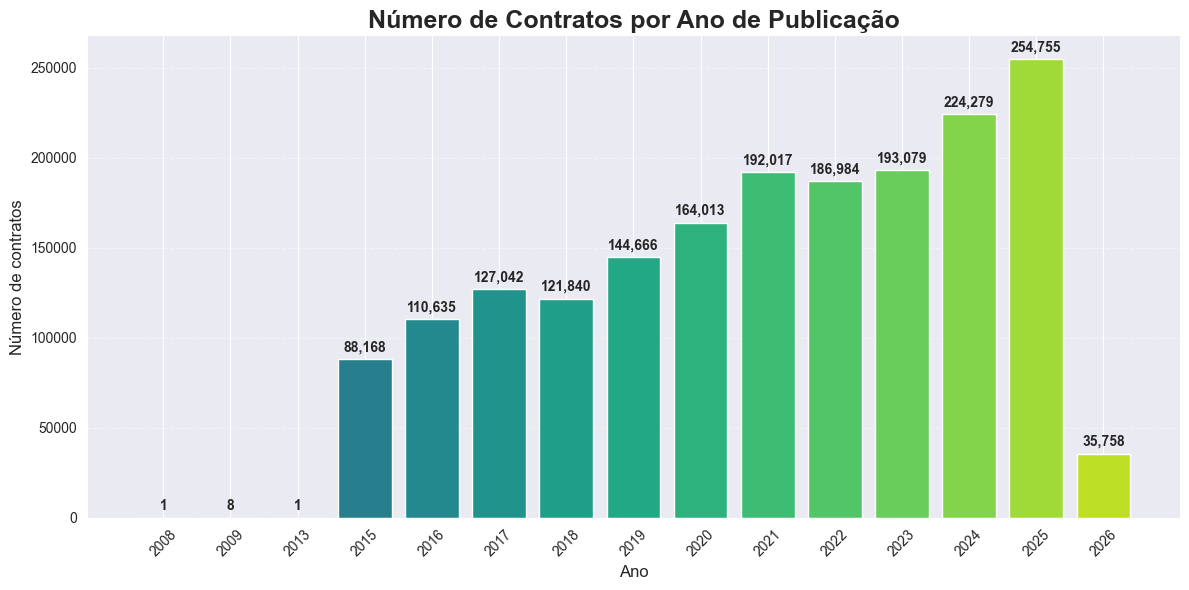

In [12]:
plt.figure(figsize=(12,6))

# Gradiente de cores
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(contratos_por_ano)))

bars = plt.bar(contratos_por_ano.index.astype(str), contratos_por_ano.values, color=colors)

# Valores em cima das barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max(contratos_por_ano.values)*0.01,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Estética
plt.title('Número de Contratos por Ano de Publicação', fontsize=18, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número de contratos', fontsize=12)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.4)

# Tirar bordas feias
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

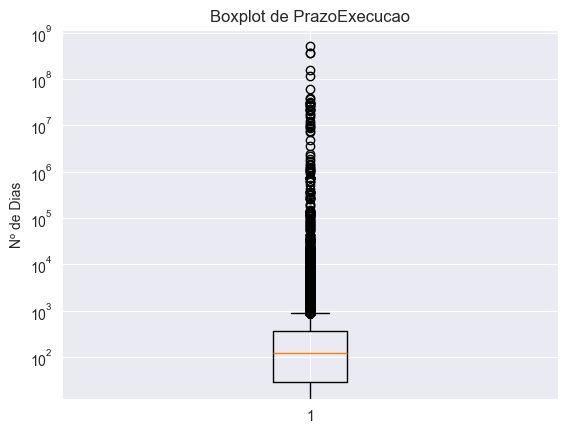

In [13]:
plt.figure()
plt.boxplot(df["prazoExecucao"].dropna())
plt.yscale("log")

plt.title("Boxplot de PrazoExecucao")
plt.ylabel("Nº de Dias")
plt.show()

In [14]:
df['PrecoTotalEfetivo'][df['PrecoTotalEfetivo']<=0].count()


np.int64(1225226)

In [15]:
df['precoBaseProcedimento'][df['precoBaseProcedimento']<=0].count()

np.int64(101548)

In [16]:
df['precoContratual'][df['precoContratual']<=0].count()

np.int64(5803)

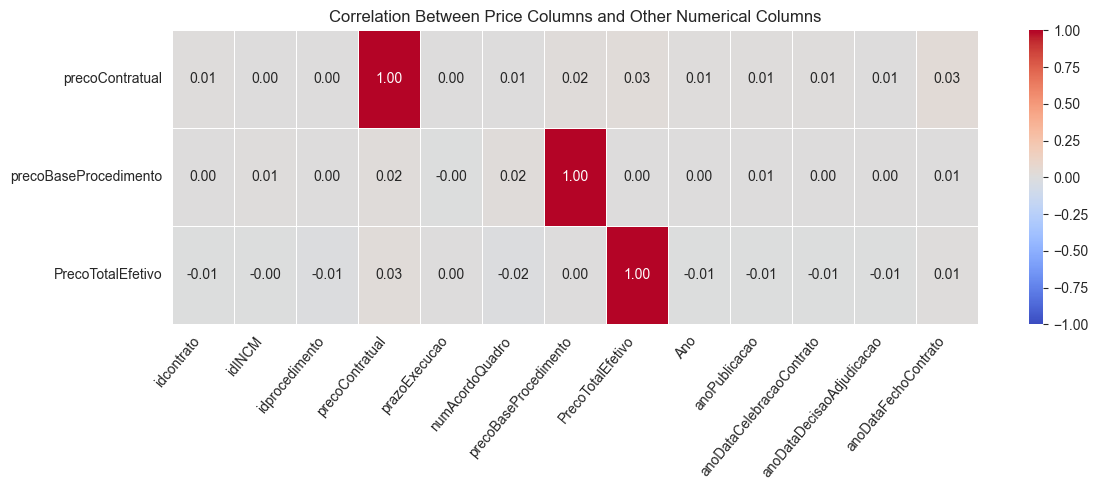

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Se quiseres criar anos a partir das datas
df["anoPublicacao"] = pd.to_datetime(df["dataPublicacao"], errors="coerce").dt.year
df["anoDataCelebracaoContrato"] = pd.to_datetime(df["dataCelebracaoContrato"], errors="coerce").dt.year
df["anoDataDecisaoAdjudicacao"] = pd.to_datetime(df["dataDecisaoAdjudicacao"], errors="coerce").dt.year
df["anoDataFechoContrato"] = pd.to_datetime(df["dataFechoContrato"], errors="coerce").dt.year

# 2) Escolher colunas numéricas relevantes
cols_corr = [
    "idcontrato",
    "idINCM",
    "idprocedimento",
    "precoContratual",
    "prazoExecucao",
    "numAcordoQuadro",
    "precoBaseProcedimento",
    "PrecoTotalEfetivo",
    "Ano",
    "anoPublicacao",
    "anoDataCelebracaoContrato",
    "anoDataDecisaoAdjudicacao",
    "anoDataFechoContrato"
]

# manter apenas as que existem no df
cols_corr = [c for c in cols_corr if c in df.columns]

# 3) Matriz de correlação
corr = df[cols_corr].corr(numeric_only=True)

# 4) Heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(
    corr.loc[["precoContratual", "precoBaseProcedimento", "PrecoTotalEfetivo"]],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Between Price Columns and Other Numerical Columns", fontsize=12)
plt.xticks(rotation=50, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
x = pd.to_numeric(df["precoContratual"], errors="coerce")

q0 = x.min()
q1 = x.quantile(0.25)
q2 = x.quantile(0.50)
q3 = x.quantile(0.75)
q4 = x.max()

tabela_intervalos = pd.DataFrame({
    "Quartil": ["Q1", "Q2", "Q3", "Q4"],
    "Intervalo (€)": [
        f"{q0:,.2f} € – {q1:,.2f} €",
        f"{q1:,.2f} € – {q2:,.2f} €",
        f"{q2:,.2f} € – {q3:,.2f} €",
        f"{q3:,.2f} € – {q4:,.2f} €"
    ]
})

tabela_intervalos["Intervalo (€)"] = tabela_intervalos["Intervalo (€)"].str.replace(",", "X").str.replace(".", ",").str.replace("X", ".")

tabela_intervalos

,Quartil,Intervalo (€)
0,Q1,"-10.566.000,00 € – 2.909,33 €"
1,Q2,"2.909,33 € – 10.346,38 €"
2,Q3,"10.346,38 € – 29.822,55 €"
3,Q4,"29.822,55 € – 1.661.362.811,55 €"


In [19]:
negativos = (x < 0).sum()
print("Número de valores negativos:", negativos)

Número de valores negativos: 173


In [ ]:
nulos = (x == 0).sum()
print("Número de valores nulos:", nulos)

Número de valores negativos: 5630
